   Row ID  Order ID Order Date Order Priority  Order Quantity       Sales  \
0       1         3 2010-10-13            Low               6    261.5400   
1      49       293 2012-10-01           High              49  10123.0200   
2      50       293 2012-10-01           High              27    244.5700   
3      80       483 2011-07-10           High              30   4965.7595   
4      85       515 2010-08-28  Not Specified              19    394.2700   

   Discount       Ship Mode     Profit  Unit Price  ...       Customer Name  \
0      0.04     Regular Air  -213.2500       38.94  ...  Muhammed MacIntyre   
1      0.07  Delivery Truck   457.8100      208.16  ...        Barry French   
2      0.01     Regular Air    46.7075        8.69  ...        Barry French   
3      0.08     Regular Air  1198.9710      195.99  ...       Clay Rozendal   
4      0.08     Regular Air    30.9400       21.78  ...      Carlos Soltero   

  Province   Region Customer Segment Product Category  \
0  Nu

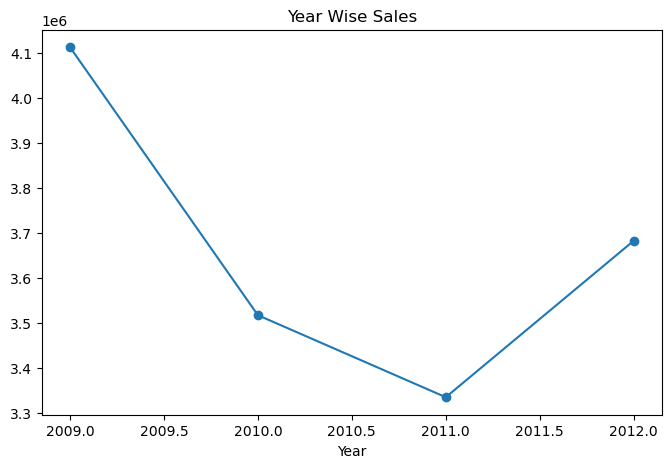

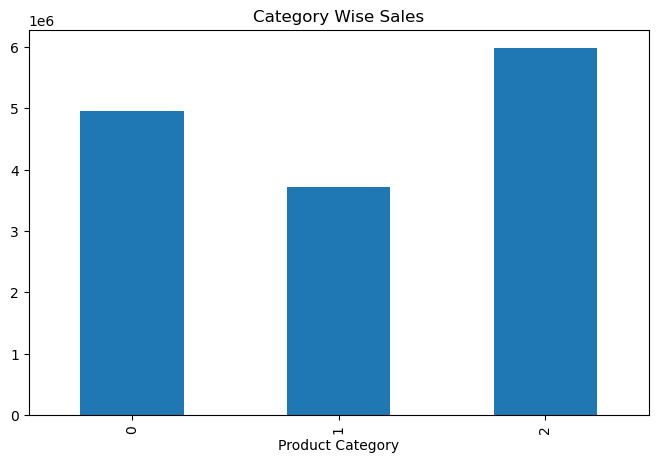

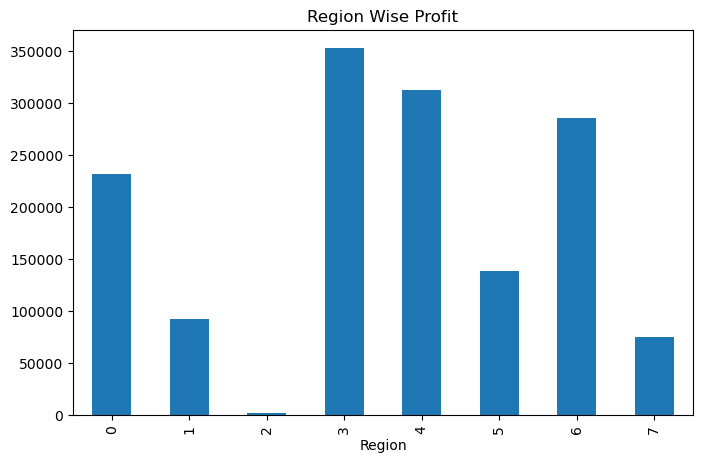

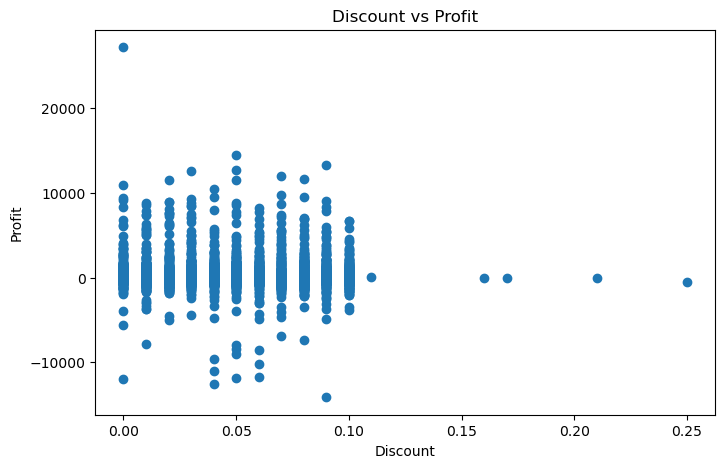

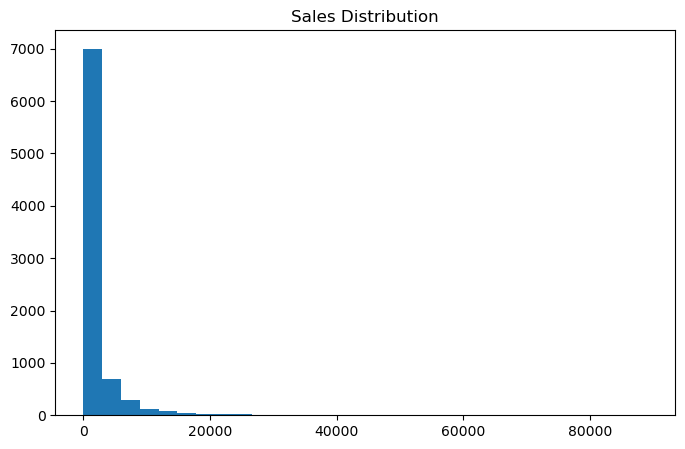

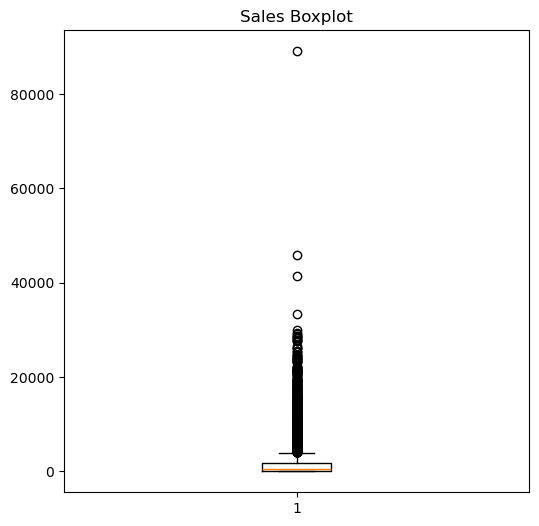

Project Completed Successfully


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===========================
# Load Dataset
# ===========================

df = pd.read_excel("Sample - Superstore Sales (Excel).xls")

print(df.head())
print(df.columns)

# ===========================
# Missing Values
# ===========================

df.dropna(inplace=True)

# ===========================
# Date
# ===========================

df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

# ===========================
# Encode Categorical Columns
# ===========================

encoder = LabelEncoder()

categorical_columns = [
    "Product Category",
    "Product Sub-Category",
    "Region",
    "Customer Segment"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# ===========================
# Features
# ===========================

X = df[
[
"Product Category",
"Product Sub-Category",
"Region",
"Customer Segment",
"Discount",
"Order Quantity",
"Unit Price",
"Shipping Cost",
"Year",
"Month"
]
]

y = df["Sales"]

# ===========================
# Train Test Split
# ===========================

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42
)

# ===========================
# Model
# ===========================

model=LinearRegression()

model.fit(X_train,y_train)

prediction=model.predict(X_test)

# ===========================
# Evaluation
# ===========================

print("MAE :",mean_absolute_error(y_test,prediction))
print("MSE :",mean_squared_error(y_test,prediction))
print("RMSE :",np.sqrt(mean_squared_error(y_test,prediction)))
print("R2 Score :",r2_score(y_test,prediction))

# ===========================
# Visualization 1
# ===========================

plt.figure(figsize=(8,5))
df.groupby("Year")["Sales"].sum().plot(marker="o")
plt.title("Year Wise Sales")
plt.show()

# ===========================
# Visualization 2
# ===========================

plt.figure(figsize=(8,5))
df.groupby("Product Category")["Sales"].sum().plot(kind="bar")
plt.title("Category Wise Sales")
plt.show()

# ===========================
# Visualization 3
# ===========================

plt.figure(figsize=(8,5))
df.groupby("Region")["Profit"].sum().plot(kind="bar")
plt.title("Region Wise Profit")
plt.show()

# ===========================
# Visualization 4
# ===========================

plt.figure(figsize=(8,5))
plt.scatter(df["Discount"],df["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

# ===========================
# Visualization 5
# ===========================

plt.figure(figsize=(8,5))
plt.hist(df["Sales"],bins=30)
plt.title("Sales Distribution")
plt.show()

# ===========================
# Visualization 6
# ===========================

plt.figure(figsize=(6,6))
plt.boxplot(df["Sales"])
plt.title("Sales Boxplot")
plt.show()

print("Project Completed Successfully")